# Filtering and Trimming Messages

## Review
Now, we have a deeper understanding of a few things:
- How to customize the graph state schema;
- How to define custom state reducers;
- How to use multiple graph state schemas.

## Goals
Now, we can start using these concepts with models in LangGraph. In the next few sessions, we will build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [4]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from pprint import pprint

from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, RemoveMessage

load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")


## Messages as State
First, let's define some messages. Recall we can pass them to a chat model.

In [2]:
messages = [
    AIMessage(f"So you said you were researching ocean mammals?", name="Bot")
]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)
llm.invoke(messages)

AIMessage(content='That\'s a great start—whales are the giants of the sea, but the world of marine mammals is incredibly diverse. Since you\'re researching, I\'d recommend diving into these groups, each with their own fascinating adaptations:\n\n**1. Dolphins & Porpoises (also cetaceans, like whales)**\nYou might already know the bottlenose dolphin, but there’s so much more. Look into the **orca** (actually the largest dolphin!), the acrobatic **spinner dolphin**, the shy **harbour porpoise**, and river dolphins like the pink **Amazon river dolphin**. They have complex social structures, echolocation, and remarkable intelligence.\n\n**2. Pinnipeds (seals, sea lions & walruses)**\nThese "fin-footed" mammals split their time between land and sea. They’re a perfect study in convergent evolution—body shapes streamlined for swimming, but with key differences:\n- **Eared seals** (sea lions and fur seals): Can walk on all fours, have visible ear flaps. The **California sea lion** is the class

We can run our chat model in a simple graph with `MessagesState`.

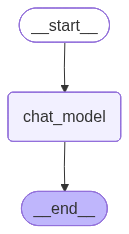

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Ah, got it—you’re following up on that earlier mention of ocean mammals and looking to broaden your knowledge beyond whales. Whales are a fantastic starting point, but the world of marine mammals is wonderfully diverse. Since you already know about whales (including the toothed whales like dolphins and porpoises, which you might already be familiar with as part of that group), let’s dive into the other major categories and some standout species you should absolutely learn about.

### 1. Pinnipeds (Seals, Sea Lions, and Walruses)
These are the “fin-footed” mammals that split their time between water and land/ice. 

In [3]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build Graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

output = graph.invoke({"messages": messages})
for m in output["messages"]:
    m.pretty_print()

## Reducer
A practical challenge when working with messages is managing long-running conversations. Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this. First, recall the trick ew saw using `RemoveMessage` and the `add_messages` reducer.


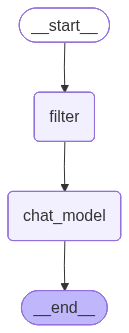

In [5]:
# Node
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build Graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({"messages": messages})
for m in output["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

It’s great that you’re building on your whale knowledge! The ocean is home to a surprising variety of other mammals, many of which behave very differently than whales. Since you’ve got whales covered, here are the other major groups worth exploring—plus a few standout species in each.

### 1. Dolphins and Porpoises (yes, they’re technically toothed whales, but often studied separately)
If you’ve mostly focused on large baleen whales or sperm whales, the smaller odontocetes are a world of their own.
- **Common bottlenose dolphin** – famous for tool use (sponges on their noses), complex social hierarchies, and sign

## Trim Messages
Another approach is to trim messages, based upon a set number of tokens. This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

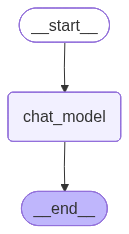

In [12]:
from langchain_core.messages import trim_messages

def simple_token_counter(messages):
    """
    Rough estimate: ~4 chars per token.
    """
    return sum(len(m.content) // 4 for m in messages)


# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        max_tokens=100,
        strategy="last",
        token_counter=simple_token_counter,
        allow_partial=False,
    )
    return {"messages": [llm.invoke(messages)]}

# Build Graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages.append(output["messages"][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))
output = graph.invoke({"messages": messages})
for m in output["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

It’s great that you’re building on your whale knowledge! The ocean is home to a surprising variety of other mammals, many of which behave very differently than whales. Since you’ve got whales covered, here are the other major groups worth exploring—plus a few standout species in each.

### 1. Dolphins and Porpoises (yes, they’re technically toothed whales, but often studied separately)
If you’ve mostly focused on large bal